<a href="https://colab.research.google.com/github/ednavivianasegura/Curso_ML_Python/blob/main/Modulo3_RedesNeuronales/RedesNeuronales_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# @title
!git clone https://github.com/ednavivianasegura/Curso_ML_Python.git

fatal: destination path 'Curso_ML_Python' already exists and is not an empty directory.


In [2]:
# @title
import os
os.chdir("/content/Curso_ML_Python/Modulo3_RedesNeuronales")
from IPython.display import HTML
import base64

## El problema del sobre Ajuste

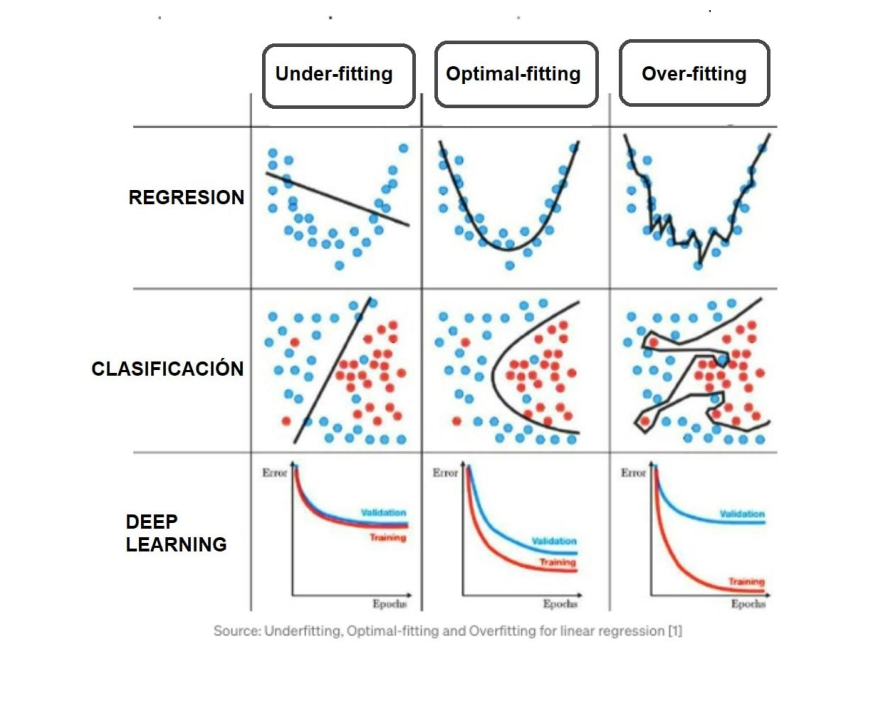

In [ ]:
# @title
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
plt.figure(figsize=(15, 9))
img = mpimg.imread('Imagenes/Sobre_Ajuste.jpg')
plt.imshow(img)
plt.axis('off')  # Opcional: oculta los ejes
plt.show()


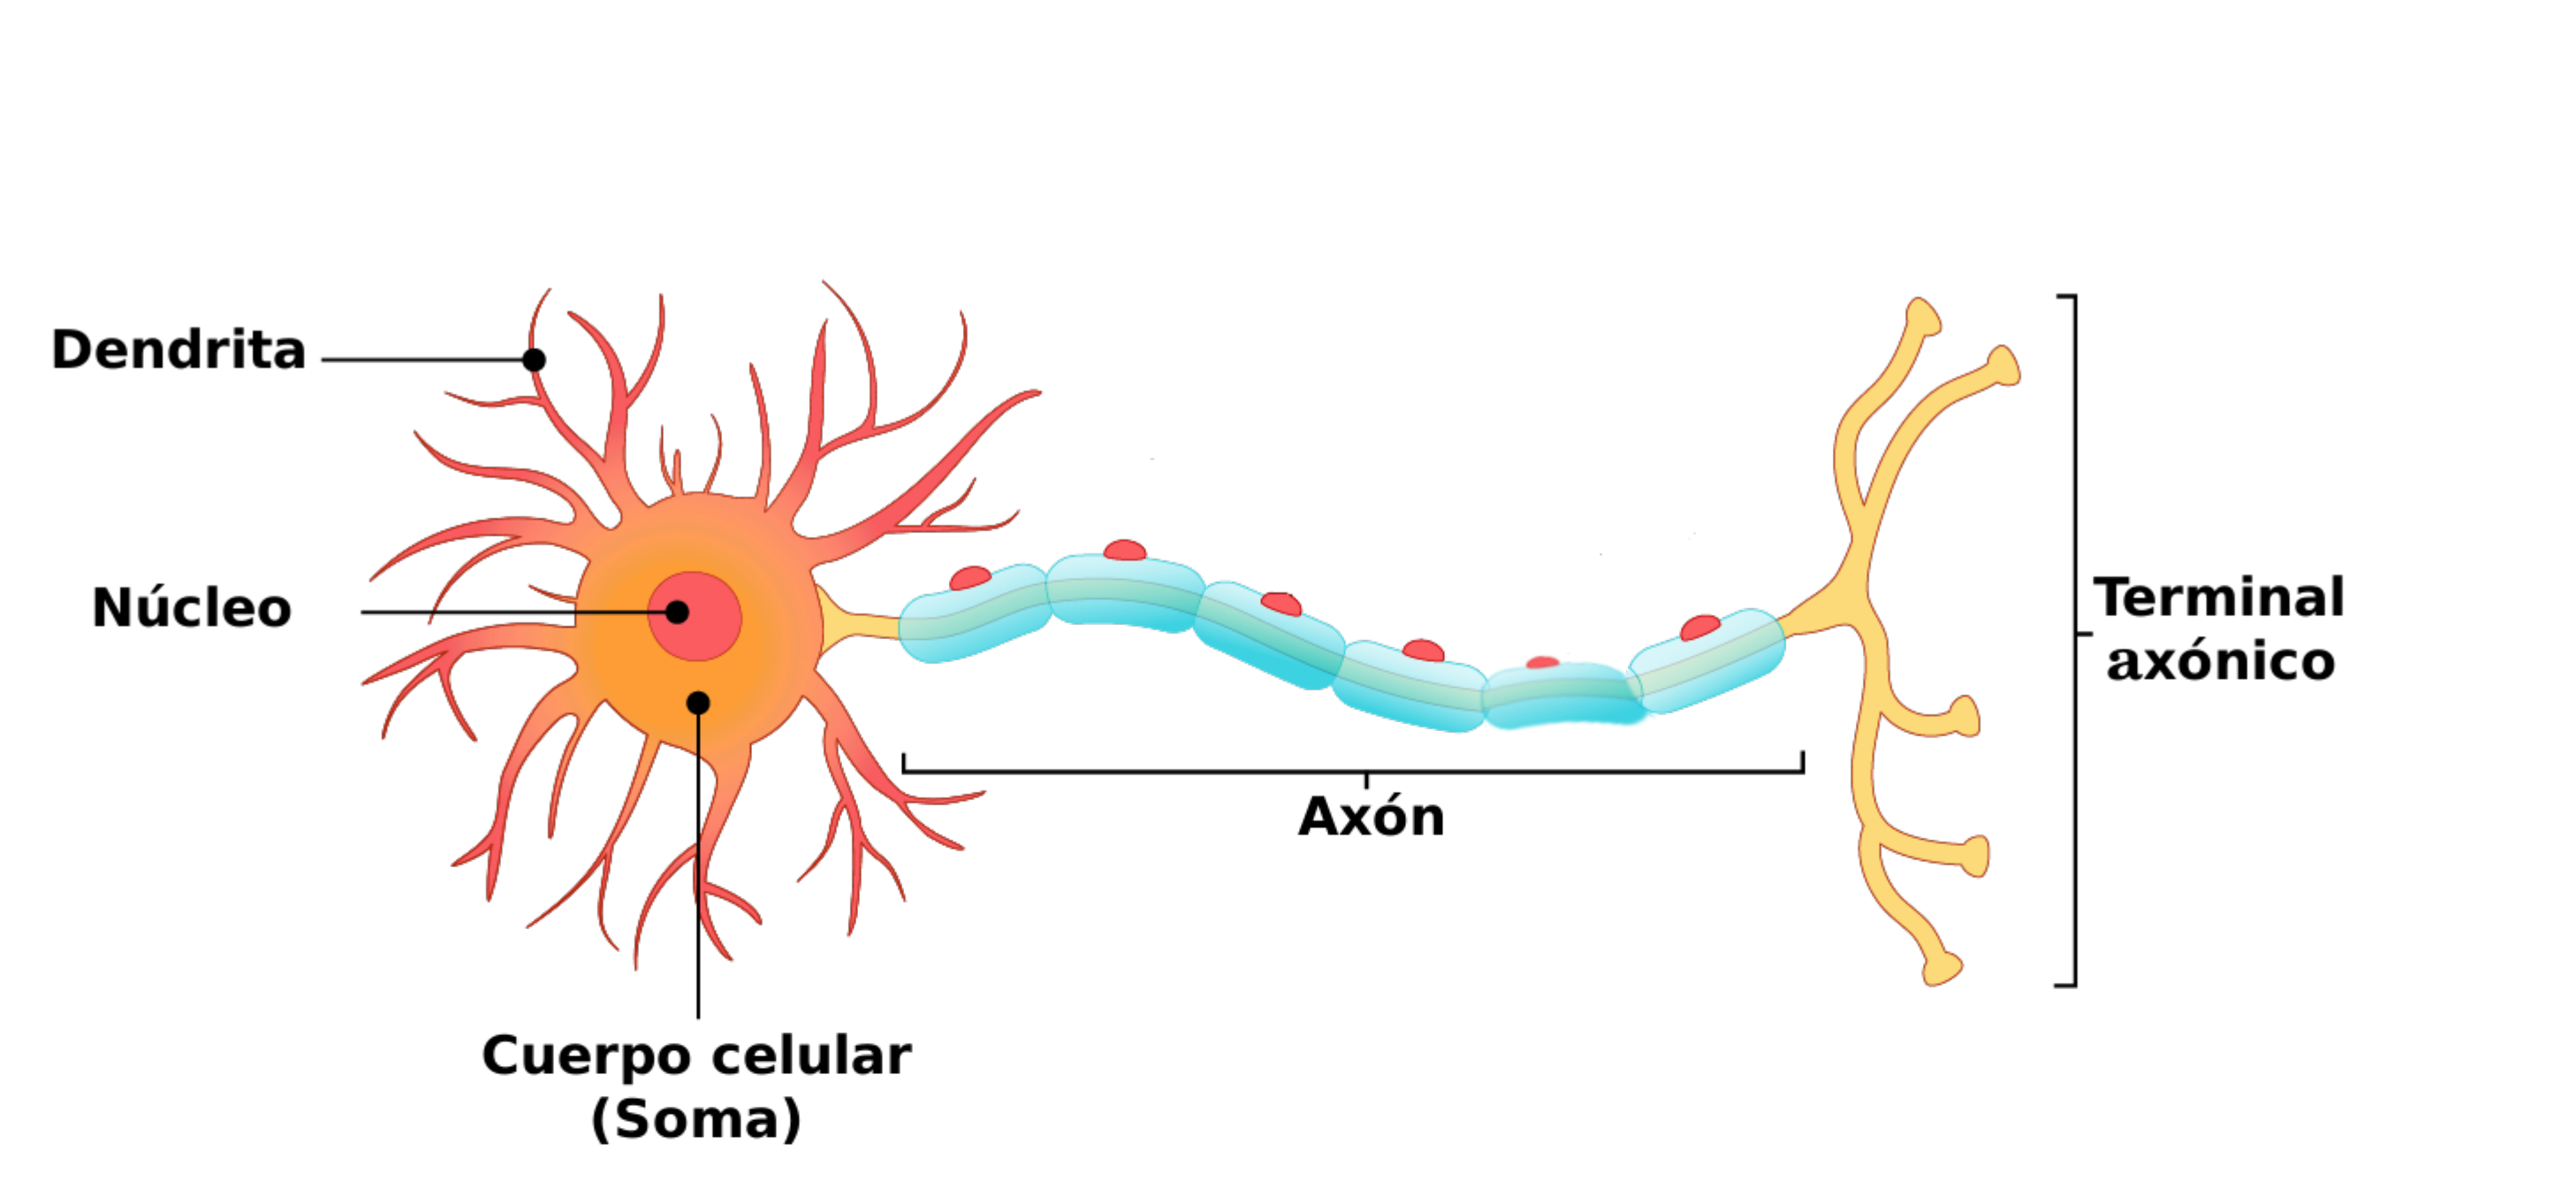

In [ ]:
# @title
# python -> base64
with open("Imagenes/NeuronEsquema.png", "rb") as image_file:
    imagen = base64.b64encode(image_file.read()).decode()

html_code = f"""

<div style="
    text-align:center;
    font-family:Arial, sans-serif;
    margin-top:20px;
">

    <h1 style="
        font-size:42px;
        color:#222;
        margin-bottom:10px;
    ">
        Redes neuronales
    </h1>

    <h2 style="
        font-size:28px;
        color:#666;
        font-weight:normal;
        font-style:italic;
        margin-bottom:30px;
    ">
        Inspiración biológica
    </h2>

    <img
        src="data:image/png;base64,{imagen}"
        style="
            width:700px;
            border-radius:12px;
            box-shadow:0px 4px 12px rgba(0,0,0,0.25);
        "
    >

</div>

"""

HTML(html_code)


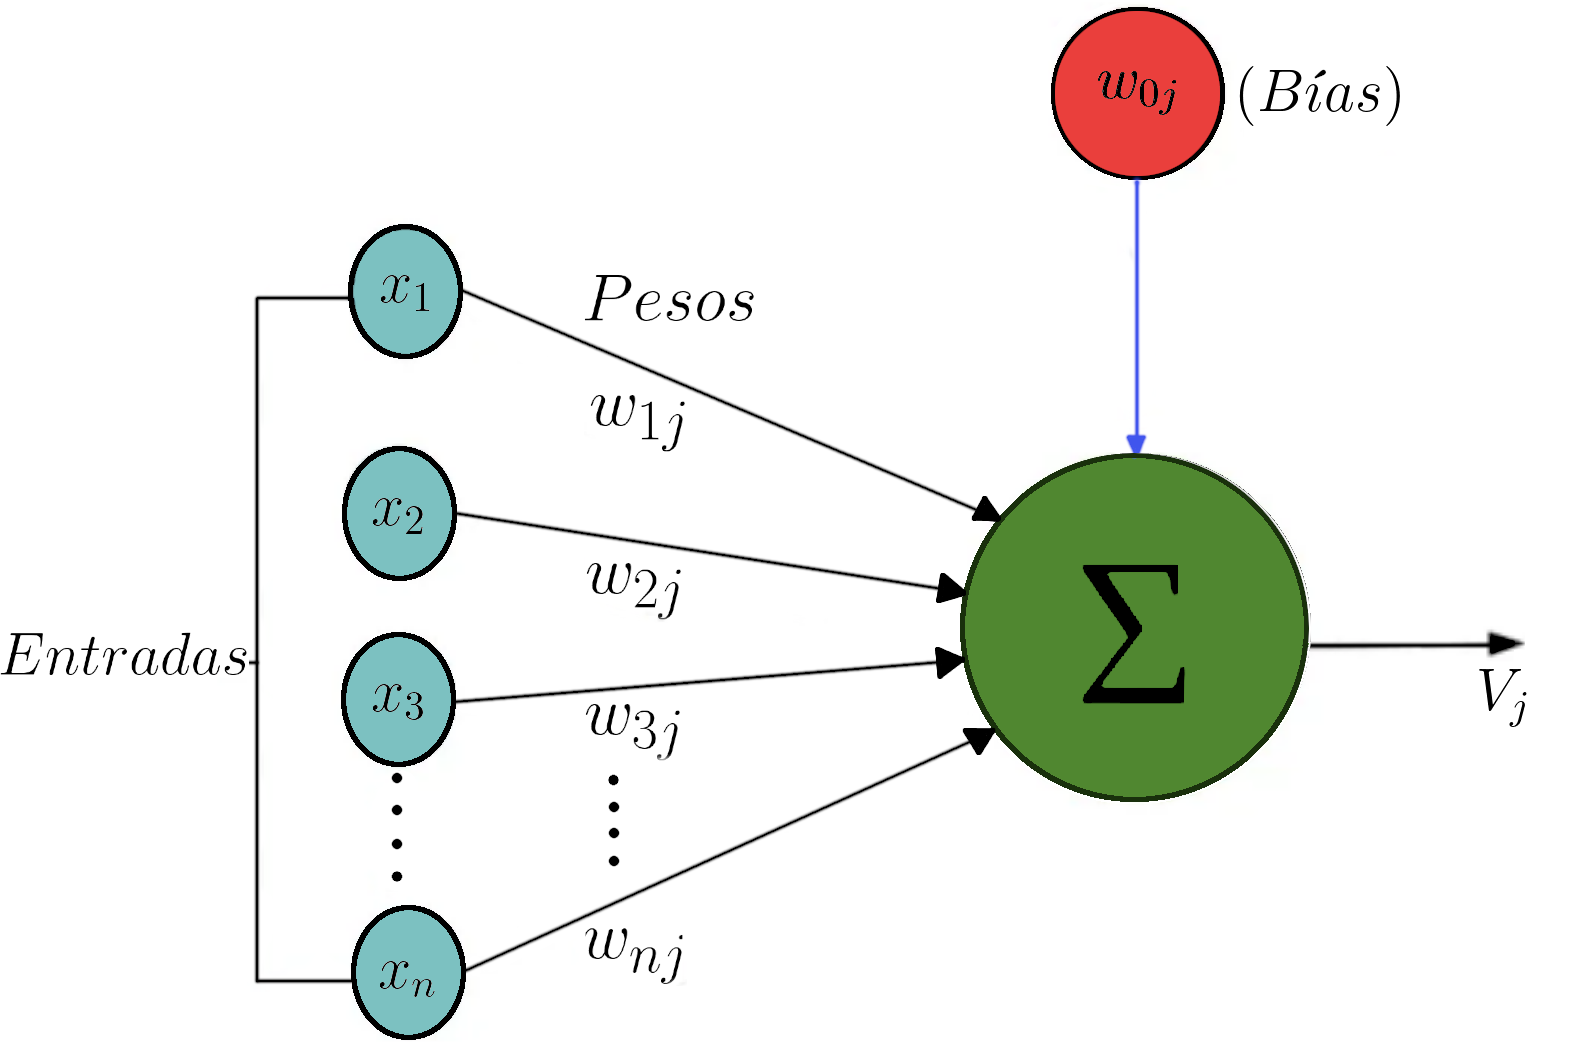

In [ ]:
# @title
with open("Imagenes/ModeloRedNeuronal.png", "rb") as image_file:
    encoded = base64.b64encode(image_file.read()).decode()

html_code = f"""

<script>
window.MathJax = {{
  tex: {{
    inlineMath: [['$', '$'], ['\\\\(', '\\\\)']],
    displayMath: [['$$','$$']]
  }}
}};
</script>

<script async
src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js">
</script>

<div style="
    text-align:center;
    font-family:Arial, sans-serif;
    margin-top:20px;
">

    <h1 style="
        font-size:42px;
        color:#222;
        margin-bottom:10px;
    ">
        Modelo matemático
    </h1>

    <br>
    <br>

    <img
        src="data:image/png;base64,{encoded}"
        style="
            width:700px;
            border-radius:12px;
            box-shadow:0px 4px 12px rgba(0,0,0,0.25);
            margin-bottom:40px;
        "
    >

    <div style="
        font-size:32px;
        color:#222;
        margin-top:20px;
    ">

    $$
    y_j = f \\left(\\sum_{{i=0}}^n x_i w_{{ij}} \\right)
    $$

    </div>

</div>

"""

HTML(html_code)

In [ ]:
# @title
html = """
<style>
  @import url('https://fonts.googleapis.com/css2?family=STIX+Two+Text:ital,wght@0,400;0,700;1,400&display=swap');

  .af-wrap {
    background: #fff;
    color: #1a1a1a;
    font-family: 'STIX Two Text', 'Times New Roman', serif;
    padding: 28px 36px;
    max-width: 900px;
  }
  .af-wrap h1 {
    font-size: 1.9rem;
    font-weight: 400;
    margin-bottom: 24px;
  }
  .af-grid {
    display: grid;
    grid-template-columns: 1fr 1fr;
    gap: 24px 40px;
  }
  .af-card {
    display: flex;
    align-items: flex-start;
    gap: 14px;
  }
  .af-label {
    flex: 0 0 148px;
  }
  .af-label h2 {
    font-size: 1rem;
    font-weight: 700;
    margin-bottom: 4px;
  }
  .af-formula {
    font-size: 0.97rem;
    line-height: 1.55;
  }
  .af-chart { flex: 1; }
  .af-chart canvas { display: block; width: 100%; }
  .piecewise-table { border-collapse: separate; border-spacing: 5px 2px; }
  .piecewise-table td:first-child { font-style: italic; }
  .piecewise-table td:last-child { color: #555; font-size: 0.87rem; }
</style>

<div class="af-wrap">
  <h1>Funciones de activación</h1>
  <div class="af-grid">

    <!-- Sigmoid -->
    <div class="af-card">
      <div class="af-label">
        <h2>Sigmoid</h2>
        <div class="af-formula">
          &sigma;(<i>x</i>) = <sup>1</sup>&frasl;<sub>1+<i>e</i><sup>&minus;<i>x</i></sup></sub>
        </div>
      </div>
      <div class="af-chart"><canvas id="af-sigmoid" width="190" height="120"></canvas></div>
    </div>

    <!-- Leaky ReLU -->
    <div class="af-card">
      <div class="af-label">
        <h2>Leaky ReLU</h2>
        <div class="af-formula">max(0.1<i>x</i>,&thinsp;<i>x</i>)</div>
      </div>
      <div class="af-chart"><canvas id="af-leakyrelu" width="190" height="120"></canvas></div>
    </div>

    <!-- tanh -->
    <div class="af-card">
      <div class="af-label">
        <h2>Tanh</h2>
        <div class="af-formula">tanh(<i>x</i>)</div>
      </div>
      <div class="af-chart"><canvas id="af-tanh" width="190" height="120"></canvas></div>
    </div>

    <!-- ELU -->
    <div class="af-card">
      <div class="af-label">
        <h2>ELU</h2>
        <div style="display:flex;align-items:center;gap:3px;margin-top:4px;">
          <span style="font-size:2.6rem;font-weight:200;line-height:1;color:#222;">{</span>
          <table class="piecewise-table">
            <tr>
              <td><i>x</i></td>
              <td><i>x</i> &ge; 0</td>
            </tr>
            <tr>
              <td><i>&alpha;</i>(<i>e<sup>x</sup></i>&minus;1)</td>
              <td><i>x</i> &lt; 0</td>
            </tr>
          </table>
        </div>
      </div>
      <div class="af-chart"><canvas id="af-elu" width="190" height="120"></canvas></div>
    </div>

    <!-- ReLU -->
    <div class="af-card">
      <div class="af-label">
        <h2>ReLU</h2>
        <div class="af-formula">max(0,&thinsp;<i>x</i>)</div>
      </div>
      <div class="af-chart"><canvas id="af-relu" width="190" height="120"></canvas></div>
    </div>

  </div>
</div>

<script>
(function() {
  function drawChart(id, fn, opts) {
    opts = opts || {};
    var canvas = document.getElementById(id);
    var W = canvas.width, H = canvas.height;
    var ctx = canvas.getContext('2d');

    var xMin = opts.xMin !== undefined ? opts.xMin : -10;
    var xMax = opts.xMax !== undefined ? opts.xMax : 10;
    var yMin = opts.yMin !== undefined ? opts.yMin : -1.2;
    var yMax = opts.yMax !== undefined ? opts.yMax : 1.2;
    var xTicks = opts.xTicks || [-10, 10];
    var yTicks = opts.yTicks !== undefined ? opts.yTicks : [-1, 1];
    var showX0 = opts.showX0 !== undefined ? opts.showX0 : true;

    var pad = { top: 10, right: 12, bottom: 20, left: 16 };
    var pw = W - pad.left - pad.right;
    var ph = H - pad.top - pad.bottom;

    function mx(x) { return pad.left + (x - xMin) / (xMax - xMin) * pw; }
    function my(y) { return pad.top + (1 - (y - yMin) / (yMax - yMin)) * ph; }

    ctx.clearRect(0, 0, W, H);

    // grid
    ctx.strokeStyle = '#e2e2e2';
    ctx.lineWidth = 0.6;
    yTicks.forEach(function(yv) {
      ctx.beginPath(); ctx.moveTo(pad.left, my(yv)); ctx.lineTo(pad.left + pw, my(yv)); ctx.stroke();
    });

    // axes
    ctx.strokeStyle = '#aaa';
    ctx.lineWidth = 0.85;
    var y0 = Math.max(yMin, Math.min(yMax, 0));
    var x0 = Math.max(xMin, Math.min(xMax, 0));
    ctx.beginPath(); ctx.moveTo(pad.left, my(y0)); ctx.lineTo(pad.left + pw, my(y0)); ctx.stroke();
    ctx.beginPath(); ctx.moveTo(mx(x0), pad.top); ctx.lineTo(mx(x0), pad.top + ph); ctx.stroke();

    // tick labels
    ctx.fillStyle = '#777';
    ctx.font = '9px serif';
    ctx.textAlign = 'center';
    ctx.textBaseline = 'top';
    xTicks.forEach(function(xv) { ctx.fillText(xv, mx(xv), my(y0) + 2); });
    if (showX0) ctx.fillText('0', mx(0) + 5, my(y0) + 2);
    ctx.textAlign = 'right';
    ctx.textBaseline = 'middle';
    yTicks.forEach(function(yv) { ctx.fillText(yv, mx(x0) - 2, my(yv)); });

    // curve
    ctx.strokeStyle = '#3a7bd5';
    ctx.lineWidth = 2.0;
    ctx.lineJoin = 'round';
    ctx.lineCap = 'round';
    ctx.beginPath();
    var first = true;
    var steps = 500;
    for (var i = 0; i <= steps; i++) {
      var x = xMin + (xMax - xMin) * i / steps;
      var y = fn(x);
      if (!isFinite(y)) { first = true; continue; }
      var cy = my(y);
      if (cy < pad.top - 2 || cy > pad.top + ph + 2) { first = true; continue; }
      if (first) { ctx.moveTo(mx(x), cy); first = false; }
      else ctx.lineTo(mx(x), cy);
    }
    ctx.stroke();
  }

  drawChart('af-sigmoid',
    function(x) { return 1 / (1 + Math.exp(-x)); },
    { yMin: -0.15, yMax: 1.15, yTicks: [1], showX0: true }
  );
  drawChart('af-tanh',
    function(x) { return Math.tanh(x); },
    { yMin: -1.2, yMax: 1.2, yTicks: [-1, 1], showX0: true }
  );
  drawChart('af-relu',
    function(x) { return Math.max(0, x); },
    { yMin: -1, yMax: 11, yTicks: [], showX0: true }
  );
  drawChart('af-leakyrelu',
    function(x) { return Math.max(0.1 * x, x); },
    { yMin: -2, yMax: 11, yTicks: [], showX0: false }
  );
  drawChart('af-elu',
    function(x) { return x >= 0 ? x : (Math.exp(x) - 1); },
    { yMin: -2.2, yMax: 11, yTicks: [-2], showX0: false }
  );
})();
</script>
"""

display(HTML(html))

x,x ≥ 0
α(ex−1),x < 0


In [ ]:
# @title
%%html
<link href="https://fonts.googleapis.com/css2?family=JetBrains+Mono:wght@400;500&family=Lato:wght@300;400;700&display=swap" rel="stylesheet">
<style>
  #nn-wrapper {
    font-family: 'Lato', sans-serif;
    background: #f8f9fc;
    display: flex;
    justify-content: center;
    padding: 24px;
  }
  #nn-card {
    background: #ffffff;
    border-radius: 16px;
    box-shadow: 0 4px 24px rgba(0,0,0,0.08), 0 1px 4px rgba(0,0,0,0.04);
    padding: 32px 28px 24px;
    max-width: 900px;
    width: 120%;
  }
  #nn-title {
    text-align: center;
    font-size: 17px;
    font-weight: 700;
    color: #1e2a3a;
    letter-spacing: 0.04em;
    text-transform: uppercase;
    margin-bottom: 24px;
  }
  #nn { display: block; width: 100%; height: auto; }
  #nn-legend {
    display: flex;
    justify-content: center;
    gap: 28px;
    margin-top: 20px;
    flex-wrap: wrap;
  }
  .nn-leg {
    display: flex;
    align-items: center;
    gap: 8px;
    font-size: 12px;
    color: #4a5568;
    font-family: 'JetBrains Mono', monospace;
  }
  .nn-dot {
    width: 16px; height: 16px;
    border-radius: 50%;
    flex-shrink: 0;
  }
</style>

<div id="nn-wrapper">
  <div id="nn-card">
    <div id="nn-title">Perceptrón Multicapa — MLP</div>
    <canvas id="nn" width="840" height="400"></canvas>
    <div id="nn-legend">
      <div class="nn-leg"><div class="nn-dot" style="background:#1e2a3a"></div>Capa de entrada</div>
      <div class="nn-leg"><div class="nn-dot" style="background:#3fb8c8"></div>Capas ocultas</div>
      <div class="nn-leg"><div class="nn-dot" style="background:#5aae6e"></div>Capa de salida</div>
    </div>
  </div>
</div>

<script>
(function() {
  var canvas = document.getElementById('nn');
  var ctx = canvas.getContext('2d');
  var W = canvas.width, H = canvas.height;

  var layers = [
    { nodes: 4, color: '#1e2a3a', border: '#1e2a3a', inputLayer: true },
    { nodes: 5, color: '#3fb8c8', border: '#2da0b0' },
    { nodes: 5, color: '#3fb8c8', border: '#2da0b0' },
    { nodes: 5, color: '#3fb8c8', border: '#2da0b0', dotsBefore: true },
    { nodes: 5, color: '#3fb8c8', border: '#2da0b0' },
    { nodes: 5, color: '#3fb8c8', border: '#2da0b0' },
    { nodes: 3, color: '#5aae6e', border: '#3d9455', outputLayer: true },
  ];

  var R = 17;
  var layerXs = [60, 190, 305, 420, 510, 600, 750];

  function nodeY(li, ni, total) {
    var yCenter = H / 2 - 28;
    var spacing = Math.min(58, (H - 100) / total);
    var totalH = (total - 1) * spacing;
    return yCenter - totalH / 2 + ni * spacing;
  }

  function drawConnection(x1, y1, x2, y2) {
    ctx.save();
    ctx.globalAlpha = 0.35;
    ctx.strokeStyle = '#b0bec5';
    ctx.lineWidth = 0.75;
    ctx.beginPath();
    ctx.moveTo(x1, y1);
    ctx.lineTo(x2, y2);
    ctx.stroke();
    ctx.restore();
  }

  function drawNode(x, y, layer) {
    ctx.save();
    ctx.shadowColor = 'rgba(0,0,0,0.15)';
    ctx.shadowBlur = 8;
    ctx.shadowOffsetY = 2;
    ctx.beginPath();
    ctx.arc(x, y, R, 0, Math.PI * 2);
    ctx.fillStyle = layer.color;
    ctx.fill();
    ctx.shadowBlur = 0;
    ctx.lineWidth = 1.5;
    ctx.strokeStyle = layer.border;
    ctx.stroke();
    ctx.restore();
  }

  function drawVDots(x, y) {
    ctx.save();
    ctx.fillStyle = '#90a0b0';
    for (var i = -1; i <= 1; i++) {
      ctx.beginPath();
      ctx.arc(x, y + i * 9, 2.5, 0, Math.PI * 2);
      ctx.fill();
    }
    ctx.restore();
  }

  function drawHDots(x, y) {
    ctx.save();
    ctx.fillStyle = '#90a0b0';
    for (var i = -1; i <= 1; i++) {
      ctx.beginPath();
      ctx.arc(x + i * 9, y, 2.5, 0, Math.PI * 2);
      ctx.fill();
    }
    ctx.restore();
  }

  function drawArrow(x1, y1, x2, y2, color) {
    var headLen = 9;
    var angle = Math.atan2(y2 - y1, x2 - x1);
    ctx.save();
    ctx.strokeStyle = color;
    ctx.lineWidth = 1.5;
    ctx.lineCap = 'round';
    ctx.beginPath();
    ctx.moveTo(x1, y1);
    ctx.lineTo(x2, y2);
    ctx.stroke();
    ctx.beginPath();
    ctx.moveTo(x2, y2);
    ctx.lineTo(x2 - headLen * Math.cos(angle - 0.4), y2 - headLen * Math.sin(angle - 0.4));
    ctx.moveTo(x2, y2);
    ctx.lineTo(x2 - headLen * Math.cos(angle + 0.4), y2 - headLen * Math.sin(angle + 0.4));
    ctx.stroke();
    ctx.restore();
  }

  function visibleNodes(li) {
    var total = layers[li].nodes;
    if (total <= 3) return Array.from({length: total}, function(_, i){ return i; });
    return [0, 1, null, total - 1];
  }

  // Connections (skip gap between layers 2 and 3)
  for (var li = 0; li < layers.length - 1; li++) {
    if (li === 2) continue;
    var nA = layers[li].nodes, nB = layers[li+1].nodes;
    for (var a = 0; a < nA; a++) {
      for (var b = 0; b < nB; b++) {
        drawConnection(
          layerXs[li] + R, nodeY(li, a, nA),
          layerXs[li+1] - R, nodeY(li+1, b, nB)
        );
      }
    }
  }

  // Horizontal dots for gap
  drawHDots((layerXs[2] + layerXs[3]) / 2, H / 2 - 28);

  // Nodes
  for (var li = 0; li < layers.length; li++) {
    var layer = layers[li];
    var x = layerXs[li];
    var visible = visibleNodes(li);
    var total = layer.nodes;

    visible.forEach(function(ni, idx) {
      if (ni === null) {
        var yPrev = nodeY(li, visible[idx-1], total);
        var yNext = nodeY(li, visible[idx+1], total);
        drawVDots(x, (yPrev + yNext) / 2);
      } else {
        var y = nodeY(li, ni, total);
        drawNode(x, y, layer);

        if (layer.inputLayer) {
          var inMap = {0:'x\u2081', 1:'x\u2082', [total-1]:'x\u2099'};
          if (inMap[ni]) {
            drawArrow(x - 38, y, x - R - 2, y, '#1e2a3a');
            ctx.save();
            ctx.font = '500 13px "JetBrains Mono", monospace';
            ctx.fillStyle = '#1e2a3a';
            ctx.textAlign = 'right';
            ctx.textBaseline = 'middle';
            ctx.fillText(inMap[ni], x - 42, y);
            ctx.restore();
          }
        }

        if (layer.outputLayer) {
          var outMap = {0:'y\u2081', [total-1]:'y\u2099'};
          if (outMap[ni]) {
            drawArrow(x + R + 2, y, x + 42, y, '#3d9455');
            ctx.save();
            ctx.font = '500 13px "JetBrains Mono", monospace';
            ctx.fillStyle = '#3d9455';
            ctx.textAlign = 'left';
            ctx.textBaseline = 'middle';
            ctx.fillText(outMap[ni], x + 46, y);
            ctx.restore();
          }
        }
      }
    });
  }

  // Bottom sublabels
  var subs = ['n\u2081','n\u2082','n\u2083','n\u1D62','n\u2C7C','n\u1D04\u207B\u00B9','n\u1D04'];
  var labelY = H - 52;
  for (var li = 0; li < layerXs.length; li++) {
    ctx.save();
    ctx.font = '400 10px "JetBrains Mono", monospace';
    ctx.fillStyle = '#94a3b8';
    ctx.textAlign = 'center';
    ctx.fillText(subs[li], layerXs[li], labelY + 6);
    ctx.restore();
  }

  // "Entrada" / "Salida" labels
  [
    {x: layerXs[0], t: 'ENTRADA'},
    {x: layerXs[6], t: 'SALIDA'}
  ].forEach(function(g) {
    ctx.save();
    ctx.font = '700 10px "Lato", sans-serif';
    ctx.fillStyle = '#64748b';
    ctx.textAlign = 'center';
    ctx.fillText(g.t, g.x, labelY + 20);
    ctx.restore();
  });

  // "Capas ocultas" bracket
  var x1 = layerXs[1], x2 = layerXs[5], yb = H - 18;
  ctx.save();
  ctx.strokeStyle = '#b0bec5';
  ctx.lineWidth = 1;
  ctx.beginPath();
  ctx.moveTo(x1 - 20, yb - 8); ctx.lineTo(x1 - 20, yb);
  ctx.lineTo(x2 + 20, yb); ctx.lineTo(x2 + 20, yb - 8);
  ctx.stroke();
  ctx.font = '700 10px "Lato", sans-serif';
  ctx.fillStyle = '#64748b';
  ctx.textAlign = 'center';
  ctx.fillText('CAPAS OCULTAS', (x1 + x2) / 2, yb + 14);
  ctx.restore();
})();
</script>

In [ ]:
# @title
%%html

<style>

body{
    background:#f4f6f9;
    font-family:Arial, sans-serif;
}

.container{
    width:90%;
    max-width:1200px;
    margin:auto;
    margin-top:30px;
    background:white;
    border-radius:18px;
    padding:50px;
    box-shadow:0px 6px 18px rgba(0,0,0,0.15);
}

/* Título principal */
.main-title{
    text-align:center;
    font-size:48px;
    font-weight:bold;
    color:#1f2937;
    margin-bottom:40px;
}

/* Secciones */
.section-title{
    font-size:34px;
    font-weight:bold;
    color:#2563eb;
    margin-top:30px;
    margin-bottom:25px;
    border-left:8px solid #2563eb;
    padding-left:18px;
}

/* Texto general */
.text{
    font-size:24px;
    color:#374151;
    line-height:1.8;
    margin-bottom:25px;
    text-align:justify;
}

/* Tarjetas */
.card{
    background:#f9fafb;
    border-left:8px solid #3b82f6;
    padding:25px;
    border-radius:14px;
    margin-bottom:25px;
    box-shadow:0px 3px 10px rgba(0,0,0,0.08);
}

/* Título de tarjeta */
.card-title{
    font-size:28px;
    font-weight:bold;
    color:#111827;
    margin-bottom:15px;
}

/* Lista */
ul{
    margin-left:30px;
}

li{
    font-size:23px;
    color:#374151;
    margin-bottom:14px;
    line-height:1.7;
}

/* Caja destacada */
.highlight{
    margin-top:40px;
    background:linear-gradient(135deg, #2563eb, #1d4ed8);
    color:white;
    padding:35px;
    border-radius:18px;
    box-shadow:0px 5px 14px rgba(0,0,0,0.2);
}

.highlight-title{
    font-size:34px;
    font-weight:bold;
    margin-bottom:20px;
}

.highlight p{
    font-size:24px;
    line-height:1.8;
}

strong{
    color:#111827;
}

.highlight strong{
    color:#ffffff;
}

</style>

<div class="container">

    <div class="main-title">
        Entrenamiento de una Red Feed-Forward
    </div>

    <div class="section-title">
        Topología de la Red
    </div>

    <div class="text">
        La <strong>topología</strong> de una red neuronal describe su estructura interna y la forma en que las neuronas se organizan y conectan entre sí.
        Esta arquitectura determina la capacidad de la red para aprender patrones, representar información y resolver problemas complejos.
    </div>

    <!-- Card 1 -->
    <div class="card">

        <div class="card-title">
            1. Número de capas
        </div>

        <ul>
            <li>
                <strong>Capa de entrada:</strong> recibe los datos iniciales que serán procesados por la red.
            </li>

            <li>
                <strong>Capas ocultas:</strong> transforman la información mediante operaciones matemáticas y funciones de activación.
            </li>

            <li>
                <strong>Capa de salida:</strong> genera la predicción o resultado final del modelo.
            </li>
        </ul>

    </div>

    <!-- Card 2 -->
    <div class="card">

        <div class="card-title">
            2. Número de neuronas por capa
        </div>

        <div class="text">
            La cantidad de neuronas influye directamente en la capacidad de aprendizaje de la red.
            Un mayor número de neuronas permite modelar relaciones más complejas, aunque también incrementa el riesgo de <strong>sobreajuste</strong>.
        </div>

    </div>

    <!-- Card 3 -->
    <div class="card">

        <div class="card-title">
            3. Tipo de conexiones
        </div>

        <div class="text">
            Las conexiones determinan cómo fluye la información dentro de la red.
            En arquitecturas recurrentes, por ejemplo, las salidas pueden retroalimentarse hacia capas anteriores, permitiendo modelar secuencias y dependencias temporales.
        </div>

    </div>

    <!-- Card 4 -->
    <div class="card">

        <div class="card-title">
            4. Funciones de activación
        </div>

        <div class="text">
            Las funciones de activación controlan la respuesta de cada neurona ante una entrada determinada.
            Algunas de las más utilizadas son:
        </div>

        <ul>
            <li><strong>ReLU:</strong> ampliamente utilizada en redes profundas.</li>
            <li><strong>Sigmoide:</strong> útil en problemas de clasificación binaria.</li>
            <li><strong>Tanh:</strong> permite salidas entre valores negativos y positivos.</li>
            <li><strong>Softmax:</strong> utilizada en clasificación multiclase.</li>
        </ul>

    </div>

    <!-- Highlight -->
    <div class="highlight">

        <div class="highlight-title">
            ¿Por qué es importante la topología?
        </div>

        <p>
            Una red con una estructura demasiado simple puede presentar
            <strong>subajuste</strong>, es decir, no lograr capturar patrones relevantes de los datos.
        </p>

        <br>

        <p>
            Por otro lado, una arquitectura excesivamente compleja puede provocar
            <strong>sobreajuste</strong>, haciendo que la red memorice los datos de entrenamiento y pierda capacidad de generalización.
        </p>

        <br>

        <p>
            Diseñar una topología adecuada depende del problema, del tamaño del conjunto de datos y, en muchos casos, de un proceso iterativo de experimentación y ajuste.
        </p>

    </div>

</div>

In [ ]:
# @title
%%html

<script>
window.MathJax = {
  tex: {
    inlineMath: [['$', '$'], ['\\(', '\\)']],
    displayMath: [['$$','$$']]
  }
};
</script>

<script async
src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js">
</script>

<style>

body{
    background:#f4f7fb;
    font-family:Arial, sans-serif;
}

/* CONTENEDOR */
.container{
    width:90%;
    max-width:1250px;
    margin:auto;
    margin-top:30px;
    background:white;
    border-radius:20px;
    padding:50px;
    box-shadow:0px 6px 20px rgba(0,0,0,0.12);
}

/* TITULO */
.main-title{
    text-align:center;
    font-size:48px;
    font-weight:bold;
    color:#111827;
    margin-bottom:45px;
}

/* SUBTÍTULOS */
.section-title{
    font-size:34px;
    font-weight:bold;
    color:#2563eb;
    margin-top:40px;
    margin-bottom:25px;
    border-left:8px solid #2563eb;
    padding-left:18px;
}

/* TEXTO */
.text{
    font-size:24px;
    color:#374151;
    line-height:1.9;
    margin-bottom:25px;
    text-align:justify;
}

/* CAJAS */
.card{
    background:#f9fafb;
    border-left:8px solid #3b82f6;
    border-radius:16px;
    padding:28px;
    margin-bottom:28px;
    box-shadow:0px 3px 10px rgba(0,0,0,0.08);
}

/* GRID */
.grid{
    display:grid;
    grid-template-columns:1fr 1fr;
    gap:25px;
    margin-top:25px;
}

/* ITEMS */
.item{
    background:white;
    border-radius:14px;
    padding:22px;
    box-shadow:0px 2px 8px rgba(0,0,0,0.08);
    border-top:6px solid #2563eb;
}

/* TITULOS ITEMS */
.item-title{
    font-size:28px;
    font-weight:bold;
    color:#1f2937;
    margin-bottom:15px;
}

/* LISTAS */
ul{
    margin-left:25px;
}

li{
    font-size:23px;
    color:#374151;
    margin-bottom:14px;
    line-height:1.7;
}

/* FORMULA */
.formula-box{
    background:#eef4ff;
    border-radius:18px;
    padding:35px;
    text-align:center;
    margin-top:25px;
    margin-bottom:25px;
    box-shadow:0px 4px 10px rgba(0,0,0,0.08);
}

.formula{
    font-size:34px;
    color:#111827;
}

/* DESTACADO */
.highlight{
    margin-top:40px;
    background:linear-gradient(135deg,#2563eb,#1d4ed8);
    color:white;
    border-radius:20px;
    padding:35px;
    box-shadow:0px 6px 15px rgba(0,0,0,0.2);
}

.highlight-title{
    font-size:34px;
    font-weight:bold;
    margin-bottom:20px;
}

.highlight p{
    font-size:24px;
    line-height:1.8;
}

/* ALERTA */
.warning{
    background:#fff4e5;
    border-left:8px solid #f59e0b;
    border-radius:16px;
    padding:30px;
    margin-top:35px;
}

.warning-title{
    font-size:30px;
    font-weight:bold;
    color:#92400e;
    margin-bottom:15px;
}

.warning p{
    font-size:24px;
    color:#78350f;
    line-height:1.8;
}

/* RESPONSIVE */
@media(max-width:900px){

    .grid{
        grid-template-columns:1fr;
    }

    .main-title{
        font-size:38px;
    }

    .section-title{
        font-size:28px;
    }

    .text, li{
        font-size:21px;
    }
}

</style>

<div class="container">

    <div class="main-title">
        Inicialización y Ajuste de los Pesos en Redes Neuronales
    </div>

    <!-- INTRO -->
    <div class="card">

        <div class="section-title">
            Importancia de la Inicialización de Pesos
        </div>

        <div class="text">
            La inicialización de los pesos es un aspecto fundamental en el entrenamiento de una red neuronal.
            Una elección adecuada puede acelerar el aprendizaje, mejorar la estabilidad numérica y facilitar la convergencia hacia soluciones óptimas.
        </div>

        <ul>
            <li>
                🔄 <strong>Velocidad de convergencia:</strong> influye directamente en qué tan rápido aprende la red durante el entrenamiento.
            </li>

            <li>
                📉 <strong>Estabilidad del entrenamiento:</strong> ayuda a evitar problemas como gradientes que desaparecen o explotan.
            </li>

            <li>
                🤖 <strong>Capacidad de aprendizaje:</strong> permite que las neuronas comiencen aprendiendo patrones diferentes desde el inicio.
            </li>
        </ul>

    </div>

    <!-- ACTUALIZACION -->
    <div class="section-title">
        Actualización de los Pesos
    </div>

    <div class="text">
        Durante el entrenamiento, cada capa ajusta sus pesos y sesgos mediante el proceso de
        <strong>retropropagación</strong> y algoritmos de optimización como el
        <strong>descenso del gradiente</strong>.
    </div>

    <div class="formula-box">

        <div class="formula">

        $$
        \Delta w = - \eta \nabla E
        $$

        </div>

    </div>

    <div class="text">
        Donde:
    </div>

    <ul>
        <li><strong>\(\Delta w\)</strong>: cambio aplicado a los pesos.</li>
        <li><strong>\(\eta\)</strong>: tasa de aprendizaje.</li>
        <li><strong>\(\nabla E\)</strong>: gradiente del error.</li>
    </ul>

    <!-- HIPERPARAMETROS -->
    <div class="section-title">
        Ajuste de Hiperparámetros
    </div>

    <div class="grid">

        <div class="item">

            <div class="item-title">
                Grid Search
            </div>

            <div class="text">
                Explora sistemáticamente diferentes combinaciones de hiperparámetros.
            </div>

        </div>

        <div class="item">

            <div class="item-title">
                Búsqueda Aleatoria
            </div>

            <div class="text">
                Selecciona configuraciones al azar, reduciendo el costo computacional.
            </div>

        </div>

        <div class="item">

            <div class="item-title">
                Búsqueda Inteligente
            </div>

            <div class="text">
                Emplea técnicas avanzadas para encontrar configuraciones eficientes de manera automática.
            </div>

        </div>

        <div class="item">

            <div class="item-title">
                Parada Temprana
            </div>

            <div class="text">
                Detiene el entrenamiento cuando el modelo deja de mejorar, evitando el sobreaprendizaje.
            </div>

        </div>

    </div>

    <!-- BUENAS PRACTICAS -->
    <div class="highlight">

        <div class="highlight-title">
            Buenas Prácticas
        </div>

        <p>
            ✔ Usa inicialización <strong>He</strong> cuando emplees funciones de activación como ReLU o LeakyReLU.
        </p>

        <br>

        <p>
            ✔ Usa inicialización <strong>Glorot (Xavier)</strong> para funciones como tanh o sigmoid.
        </p>

        <br>

        <p>
            ✔ Frameworks como PyTorch, TensorFlow y Keras suelen seleccionar automáticamente una inicialización adecuada según la función de activación utilizada.
        </p>

    </div>

    <!-- MALA PRACTICA -->
    <div class="warning">

        <div class="warning-title">
            ⚠ Mala práctica: Inicializar todos los pesos con el mismo valor
        </div>

        <p>
            Inicializar todos los pesos en cero o uno provoca que todas las neuronas aprendan exactamente lo mismo.
            Como consecuencia, la red pierde diversidad en las representaciones internas y no logra aprender correctamente.
        </p>

    </div>

    <!-- CNN -->
    <div class="section-title">
        Capas Convolucionales
    </div>

    <div class="text">
        Las estrategias de inicialización como He y Glorot también son ampliamente utilizadas en redes neuronales convolucionales (CNN), ya que contribuyen a mantener la estabilidad del entrenamiento en arquitecturas profundas.
    </div>

    <!-- EJEMPLO -->
    <div class="section-title">
        Ejemplo: Clasificación Multiclase
    </div>

    <div class="text">
        En problemas de clasificación multiclase, la capa de salida suele utilizar la función
        <strong>Softmax</strong>, mientras que la función de pérdida más común es
        <strong>Categorical Crossentropy</strong>.
    </div>

    <div class="grid">

        <div class="item">

            <div class="item-title">
                Componentes de una Red Neuronal
            </div>

            <ul>
                <li>Capa de entrada</li>
                <li>Capas ocultas</li>
                <li>Capa de salida</li>
            </ul>

        </div>

        <div class="item">

            <div class="item-title">
                Funciones de Activación Comunes
            </div>

            <ul>
                <li>ReLU (Rectified Linear Unit)</li>
                <li>Sigmoid</li>
                <li>Tanh</li>
            </ul>

        </div>

    </div>

</div>

In [24]:
# 1. Librerías requeridas.

# Cálculo y visualización
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesado de datos
from sklearn.datasets          import load_wine
from   sklearn.model_selection import train_test_split
from   sklearn.preprocessing   import StandardScaler
from   sklearn.metrics         import classification_report, confusion_matrix

# Aprendizaje profundo
import torch
import torch.nn as nn
import torch.optim as optim
from   torch.utils.data import DataLoader, TensorDataset, random_split

# Selección de tarjeta gráfica si está disponible
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"   Dispositivo: {DEVICE}")

# Postureo
from   rich import print

Dispositivo: cpu

In [25]:
# 2. Cargar el dataset:  Wine dataset (3 clases)
wine = load_wine(as_frame=True)
df = wine.frame  # DataFrame completo con las 13 características y la columna 'target'

# Separar explícitamente X e y:
X = df[wine.feature_names]  # Solo las características
y = df['target']            # Solo la variable objetivo



In [26]:
y

,target
0,0
1,0
2,0
3,0
4,0
...,...
173,2
174,2
175,2
176,2


In [ ]:
#@title Selección de parámetros de entrenamiento e hiperparámetros de la red

# =========================
# Fila 1: División de datos
# =========================
test_data   = 0.2 #@param {type:"slider", min:0, max:0.4, step:0.01}
valid_data  = 0.1 #@param {type:"slider", min:0, max:0.4, step:0.01}
batch_size  = 8   #@param {type:"integer"}

train_data = (1 - test_data) * (1 - valid_data)
print(f"Se va a entrenar con un {train_data*100:.2f}% de la totalidad de los datos")


# =========================
# Fila 2: Arquitectura de la red
# =========================
layer_1   = 16 #@param {type:"integer"}
layer_2   = 10 #@param {type:"integer"}
layer_out = 3  #@param {type:"integer"}  # 3 clases


# =========================
# Fila 3: Entrenamiento
# =========================
learning_rate = 0.01 #@param {type:"number"}
epochs        = 100  #@param {type:"integer"}
optimizer     = "adam" #@param ["adam", "sgd", "rmsprop"]

Se va a entrenar con un 72.00% de la totalidad de los datos

In [ ]:
# 3. Preprocesamiento de datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# En PyTorch usamos etiquetas enteras, "CrossEntropyLoss" las convierte internamente
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y.values,test_size=test_data, random_state=42, stratify=y)

# Convertir a tensores de PyTorch
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_test_t  = torch.tensor(y_test,  dtype=torch.long)

# Crear datasets y separar validación (% del entrenamiento)
train_dataset_full = TensorDataset(X_train_t, y_train_t)

val_size   = int(valid_data * len(train_dataset_full))
train_size = len(train_dataset_full) - val_size

train_dataset, val_dataset = random_split(train_dataset_full, [train_size, val_size],generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)

In [ ]:
# 4. Construcción del modelo con PyTorch
class WineNet(nn.Module):
    def __init__(self, input_dim):
        super(WineNet, self).__init__()
        self.fc1     = nn.Linear(input_dim, layer_1)
        self.relu1   = nn.ReLU()
        self.fc2     = nn.Linear(layer_1, layer_2)
        self.relu2   = nn.ReLU()
        self.fc3     = nn.Linear(layer_2, layer_out)

    def forward(self, x):
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        x = self.fc3(x)
        return x

model     = WineNet(input_dim=X_train_t.shape[1])
criterion = nn.CrossEntropyLoss()          # equivalente a categorical_crossentropy + softmax
optimizer = optim.Adam(model.parameters()) # equivalente a optimizer='adam'
print(model)

WineNet(
  (fc1): Linear(in_features=13, out_features=16, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=16, out_features=10, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=10, out_features=3, bias=True)
)

In [ ]:
# @title
%%html

<script>
window.MathJax = {
  tex: {
    inlineMath: [['$', '$'], ['\\(', '\\)']],
    displayMath: [['$$','$$']]
  }
};
</script>

<script async
src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js">
</script>

<style>

body{
    background:#f4f7fb;
    font-family:Arial, sans-serif;
}

/* CONTENEDOR */
.container{
    width:90%;
    max-width:1300px;
    margin:auto;
    margin-top:30px;
    background:white;
    border-radius:22px;
    padding:55px;
    box-shadow:0px 6px 22px rgba(0,0,0,0.12);
}

/* TITULO */
.main-title{
    text-align:center;
    font-size:50px;
    font-weight:bold;
    color:#111827;
    margin-bottom:50px;
}

/* SECCIONES */
.section-title{
    font-size:36px;
    font-weight:bold;
    color:#2563eb;
    margin-top:45px;
    margin-bottom:25px;
    border-left:8px solid #2563eb;
    padding-left:18px;
}

/* TEXTO */
.text{
    font-size:24px;
    color:#374151;
    line-height:1.9;
    margin-bottom:25px;
    text-align:justify;
}

/* CAJAS */
.card{
    background:#f9fafb;
    border-radius:18px;
    padding:30px;
    margin-top:25px;
    margin-bottom:25px;
    box-shadow:0px 4px 12px rgba(0,0,0,0.08);
    border-left:8px solid #2563eb;
}

/* FORMULAS */
.formula-box{
    background:#eef4ff;
    border-radius:18px;
    padding:35px;
    margin-top:25px;
    margin-bottom:25px;
    text-align:center;
    box-shadow:0px 4px 10px rgba(0,0,0,0.08);
}

.formula{
    font-size:34px;
    color:#111827;
}

/* LISTAS */
ul{
    margin-left:30px;
}

li{
    font-size:23px;
    color:#374151;
    margin-bottom:16px;
    line-height:1.8;
}

/* EJEMPLO */
.example{
    background:linear-gradient(135deg,#2563eb,#1d4ed8);
    color:white;
    border-radius:20px;
    padding:35px;
    margin-top:35px;
    margin-bottom:35px;
    box-shadow:0px 6px 15px rgba(0,0,0,0.18);
}

.example-title{
    font-size:34px;
    font-weight:bold;
    margin-bottom:20px;
}

.example p{
    font-size:24px;
    line-height:1.9;
}

/* INTERPRETACION */
.highlight{
    background:#ecfdf5;
    border-left:8px solid #10b981;
    border-radius:18px;
    padding:30px;
    margin-top:35px;
}

.highlight-title{
    font-size:32px;
    font-weight:bold;
    color:#065f46;
    margin-bottom:18px;
}

.highlight p{
    font-size:24px;
    color:#064e3b;
    line-height:1.9;
}

/* RESPONSIVE */
@media(max-width:900px){

    .main-title{
        font-size:40px;
    }

    .section-title{
        font-size:30px;
    }

    .text, li{
        font-size:21px;
    }

    .formula{
        font-size:28px;
    }
}

</style>

<div class="container">

    <div class="main-title">
        Función Softmax y Categorical Crossentropy
    </div>

    <div class="text">
        Antes de continuar con el entrenamiento de redes neuronales, es importante comprender dos conceptos fundamentales utilizados en problemas de clasificación multiclase:
    </div>

    <!-- SOFTMAX -->
    <div class="section-title">
        Función Softmax
    </div>

    <div class="card">

        <div class="text">
            La función <strong>Softmax</strong> transforma un vector de valores reales en un vector de probabilidades.
            Cada valor de salida estará comprendido entre 0 y 1, y la suma total de todas las probabilidades será igual a 1.
        </div>

        <div class="text">
            Esta función se utiliza comúnmente en la capa de salida de modelos de clasificación multiclase:
        </div>

        <div class="formula-box">

            <div class="formula">

            $$
            \text{softmax}(z_i)=
            \frac{e^{z_i}}
            {\sum_{j=1}^{K} e^{z_j}}
            $$

            </div>

        </div>

        <div class="text">
            Donde:
        </div>

        <ul>
            <li><strong>\(z_i\)</strong>: logit o valor de entrada para la clase \(i\).</li>

            <li><strong>\(K\)</strong>: número total de clases.</li>

            <li>
                La salida representa la probabilidad de que el ejemplo pertenezca a la clase \(i\).
            </li>
        </ul>

    </div>

    <!-- EJEMPLO SOFTMAX -->
    <div class="example">

        <div class="example-title">
            Ejemplo Numérico
        </div>

        <p>
            Supongamos que la red neuronal produce el siguiente vector:
        </p>

        <div class="formula-box">

            <div class="formula">

            $$
            z=[2.0,\ 1.0,\ 0.1]
            $$

            </div>

        </div>

        <p>
            Después de aplicar la función Softmax:
        </p>

        <div class="formula-box">

            <div class="formula">

            $$
            \text{softmax}(z)\approx[0.659,\ 0.242,\ 0.099]
            $$

            </div>

        </div>

        <p>
            Esto significa que el modelo considera que:
        </p>

        <ul>
            <li>La clase 0 tiene aproximadamente un 65.9% de probabilidad.</li>
            <li>La clase 1 tiene aproximadamente un 24.2% de probabilidad.</li>
            <li>La clase 2 tiene aproximadamente un 9.9% de probabilidad.</li>
        </ul>

    </div>

    <!-- CATEGORICAL CROSSENTROPY -->
    <div class="section-title">
        Función de Pérdida: Categorical Crossentropy
    </div>

    <div class="card">

        <div class="text">
            La función <strong>Categorical Crossentropy (CCE)</strong> se utiliza para medir qué tan diferentes son las probabilidades predichas por el modelo respecto a las etiquetas reales.
        </div>

        <div class="text">
            Esta función es ampliamente utilizada en problemas de clasificación multiclase, especialmente cuando la capa de salida emplea la función Softmax.
        </div>

        <div class="formula-box">

            <div class="formula">

            $$
            \text{CCE}(y,\hat{y})
            =
            -\sum_{i=1}^{K}
            y_i \cdot \log(\hat{y}_i)
            $$

            </div>

        </div>

        <div class="text">
            Donde:
        </div>

        <ul>
            <li><strong>\(y\)</strong>: vector real codificado en formato one-hot.</li>

            <li><strong>\(\hat{y}\)</strong>: probabilidades predichas por el modelo.</li>

            <li><strong>\(K\)</strong>: número total de clases.</li>
        </ul>

    </div>

    <!-- EJEMPLO CCE -->
    <div class="example">

        <div class="example-title">
            Ejemplo de Categorical Crossentropy
        </div>

        <p>
            Supongamos que tenemos tres clases y que el vector real es:
        </p>

        <div class="formula-box">

            <div class="formula">

            $$
            y=[0,\ 1,\ 0]
            $$

            </div>

        </div>

        <p>
            El modelo predice las siguientes probabilidades:
        </p>

        <div class="formula-box">

            <div class="formula">

            $$
            \hat{y}=[0.1,\ 0.7,\ 0.2]
            $$

            </div>

        </div>

        <p>
            Entonces la pérdida será:
        </p>

        <div class="formula-box">

            <div class="formula">

            $$
            \text{CCE}
            =
            -(0\cdot\log0.1
            +
            1\cdot\log0.7
            +
            0\cdot\log0.2)
            $$

            </div>

        </div>

        <div class="formula-box">

            <div class="formula">

            $$
            \text{CCE}
            =
            -\log0.7
            \approx
            0.357
            $$

            </div>

        </div>

    </div>

    <!-- INTERPRETACION -->
    <div class="highlight">

        <div class="highlight-title">
            Interpretación
        </div>

        <p>
            ✔ Cuando la probabilidad predicha para la clase correcta se acerca a 1, la pérdida disminuye.
        </p>

        <br>

        <p>
            ✔ Cuando el modelo asigna baja probabilidad a la clase correcta, la pérdida aumenta significativamente.
        </p>

        <br>

        <p>
            ✔ El objetivo del entrenamiento es minimizar esta pérdida para mejorar la precisión del modelo.
        </p>

    </div>

</div>

In [ ]:
# 5. Entrenamiento
def evaluate_loader(loader):
    """Calcula loss y accuracy sobre un DataLoader."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for Xb, yb in loader:
            logits = model(Xb)
            total_loss += criterion(logits, yb).item() * len(yb)
            correct    += (logits.argmax(1) == yb).sum().item()
            total      += len(yb)
    return total_loss / total, correct / total

history = {'accuracy': [], 'val_accuracy': [], 'loss': [], 'val_loss': []}

EPOCHS = 50
for epoch in range(1, EPOCHS + 1):
    # — Fase de entrenamiento —
    model.train()
    for Xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(Xb), yb)
        loss.backward()
        optimizer.step()

    # — Métricas al final de cada época —
    train_loss, train_acc = evaluate_loader(train_loader)
    val_loss,   val_acc   = evaluate_loader(val_loader)

    history['loss'].append(train_loss)
    history['accuracy'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_accuracy'].append(val_acc)

Precisión en el conjunto de entrenamiento: 1.0000

Reporte de clasificación:

precision    recall  f1-score   support

           0       1.00      1.00      1.00        47
           1       1.00      1.00      1.00        57
           2       1.00      1.00      1.00        38

    accuracy                           1.00       142
   macro avg       1.00      1.00      1.00       142
weighted avg       1.00      1.00      1.00       142

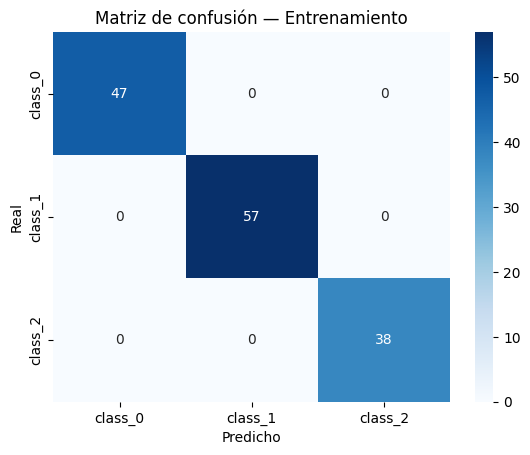

In [ ]:
# 6. Evaluación en entrenamiento (sobre TODO X_train, no sólo el subconjunto)
full_train_loader = DataLoader(TensorDataset(X_train_t, y_train_t),
                               batch_size=32, shuffle=False)
train_loss_final, train_acc_final = evaluate_loader(full_train_loader)
print(f"\nPrecisión en el conjunto de entrenamiento: {train_acc_final:.4f}")

# Predicciones y reporte
model.eval()
with torch.no_grad():
    logits_train = model(X_train_t)
y_pred = logits_train.argmax(1).numpy()
y_true = y_train_t.numpy()

print("\nReporte de clasificación:")
print(classification_report(y_true, y_pred))

# Matriz de confusión — entrenamiento
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=wine.target_names, yticklabels=wine.target_names)
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de confusión — Entrenamiento")
plt.show()

Precisión en el conjunto de prueba: 0.9722

Reporte de clasificación:

precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.93      1.00      0.97        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36

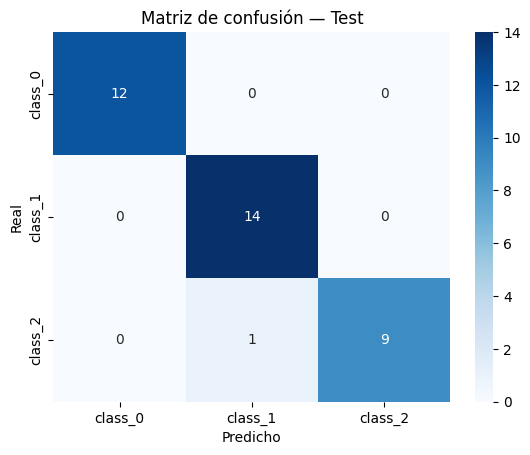

In [ ]:
# 7. Evaluación en test
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t),
                         batch_size=batch_size, shuffle=False)
test_loss_final, test_acc_final = evaluate_loader(test_loader)
print(f"\nPrecisión en el conjunto de prueba: {test_acc_final:.4f}")

# Predicciones y reporte
model.eval()
with torch.no_grad():
    logits_test = model(X_test_t)
y_pred = logits_test.argmax(1).numpy()
y_true = y_test_t.numpy()

print("\nReporte de clasificación:")
print(classification_report(y_true, y_pred, target_names=wine.target_names))

# Matriz de confusión — test
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=wine.target_names, yticklabels=wine.target_names)
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de confusión — Test")
plt.show()

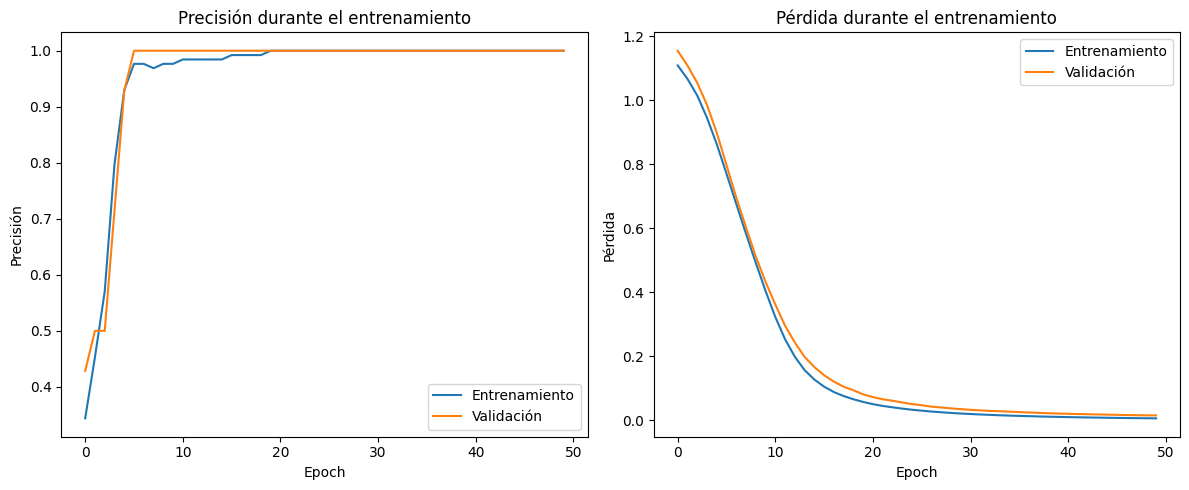

In [ ]:
# 8. Visualización del entrenamiento
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['accuracy'],     label='Entrenamiento')
plt.plot(history['val_accuracy'], label='Validación')
plt.title('Precisión durante el entrenamiento')
plt.xlabel('Epoch')
plt.ylabel('Precisión')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['loss'],     label='Entrenamiento')
plt.plot(history['val_loss'], label='Validación')
plt.title('Pérdida durante el entrenamiento')
plt.xlabel('Epoch')
plt.ylabel('Pérdida')
plt.legend()

plt.tight_layout()
plt.show()

### Para hacer una predicción manual

In [ ]:
# Nuevo dato
nuevo_dato_crudo = [13.2, 2.77, 2.51, 18.5, 98.0,
                    2.4, 2.64, 0.3, 1.46, 5.28,
                    1.02, 3.58, 820.0]

# Convertir a arreglo 2D (1 muestra, 13 características)
nuevo_dato = np.array(nuevo_dato_crudo).reshape(1, -1)

# Escalar usando EL MISMO scaler del entrenamiento
nuevo_dato_scaled = scaler.transform(nuevo_dato)

# Convertir a tensor
nuevo_tensor = torch.tensor(nuevo_dato_scaled, dtype=torch.float32)

# Poner el modelo en modo evaluación
model.eval()

# Desactivar gradientes y predecir
with torch.no_grad():
    logits = model(nuevo_tensor)

    # Clase predicha
    clase_predicha = torch.argmax(logits, dim=1).item()

# Mostrar resultado
print(f"Clase predicha: {clase_predicha}")
print(f"Nombre de la clase: {wine.target_names[clase_predicha]}")


Clase predicha: 1

Nombre de la clase: class_1

In [32]:
# @title
print("---"*345)

-------------------------------------------------------------------------------------------------------------------
-------------------------------------------------------------------------------------------------------------------
-------------------------------------------------------------------------------------------------------------------
-------------------------------------------------------------------------------------------------------------------
-------------------------------------------------------------------------------------------------------------------
-------------------------------------------------------------------------------------------------------------------
-------------------------------------------------------------------------------------------------------------------
-------------------------------------------------------------------------------------------------------------------
-------------------------------------------------------------------------------------------------------------------

In [10]:
# 1. Librerías requeridas.

# Cálculo y visualización
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesado de datos
from   sklearn.datasets        import load_wine
from   sklearn.model_selection import train_test_split
from   sklearn.preprocessing   import StandardScaler
from   sklearn.metrics         import classification_report, confusion_matrix

# Aprendizaje profundo
import torch                                                                 # 👈 tensores, operaciones,funciones de activación, generación aleatoria
import torch.nn as nn                                                        # 👈 capas predefinidas, funciones de pérdida, módulos base, capas de activación, contenedores
import torch.optim as optim                                                  # 👈 algoritmos para actualizar los pesos, control de learning rate
from   torch.utils.data import DataLoader, TensorDataset, random_split       # 👈 iteradores que cargan datos en mini-batches, mezcla automática, carga en paralelo

# Tarjeta gráfica
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"   Dispositivo: {DEVICE}")

# Postureo
from   rich import print

Dispositivo: cpu

In [13]:
# 2. Leer los datos
df = pd.read_csv("/content/Curso_ML_Python/Modulo2_Fundamentos_AI/data/drone_telemetry.csv")
df.columns

Index(['timestamp', 'time_s', 'mission_id', 'mission_phase', 'lat', 'lon',
       'alt_m', 'speed_ms', 'gps_satellites', 'hdop', 'roll_deg', 'pitch_deg',
       'yaw_deg', 'acc_x_g', 'acc_y_g', 'acc_z_g', 'gyro_x_dps', 'gyro_y_dps',
       'gyro_z_dps', 'battery_pct', 'voltage_v', 'current_a', 'motor_temp_c',
       'rssi_dbm', 'anomaly', 'anomaly_type'],
      dtype='object')

In [14]:
# ─────────────────────────────────────────────────────────
# 3. Seleccionar las variables de entrenamiento
# ─────────────────────────────────────────────────────────
df["attitude_mag"]   = np.sqrt(df["roll_deg"]**2 + df["pitch_deg"]**2)
df["power"]          = df["voltage_v"] * df["current_a"]
df["battery_drop"]   = df["battery_pct"].diff().fillna(0) * -1
df["temp_rise"]      = df["motor_temp_c"].diff().fillna(0)
df["signal_quality"] = (df["rssi_dbm"] + 100).clip(0, 60)

FEATURES = ["alt_m", "speed_ms", "attitude_mag", "battery_pct", "battery_drop",
            "power", "motor_temp_c", "temp_rise", "signal_quality", "hdop",
            "acc_z_g", "current_a"]

X = df[FEATURES].values
y = df["anomaly"].values

In [23]:
df["anomaly"].sum()

np.int64(315)

In [ ]:
# 3. Preprocesamiento de datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# En PyTorch usamos etiquetas enteras, "CrossEntropyLoss" las convierte internamente
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y.values,test_size=test_data, random_state=42, stratify=y)

# Convertir a tensores de PyTorch
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_test_t  = torch.tensor(y_test,  dtype=torch.long)

# Crear datasets y separar validación (% del entrenamiento)
train_dataset_full = TensorDataset(X_train_t, y_train_t)

val_size   = int(valid_data * len(train_dataset_full))
train_size = len(train_dataset_full) - val_size

train_dataset, val_dataset = random_split(train_dataset_full, [train_size, val_size],generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)

# Actividad en clase

Vamos a entrenar una red para que aprenda a clasificar los diferentes animales, deacuerdo a las carácterísticas dadas en la base de datos

Características importantes:

7 clases de animales:

      - Mamífero

      - Ave

      - Reptil

      - Pez

      - Anfibio

      - Insecto

      - Invertebrado

In [ ]:
# 1. Cargar y preparar los datos
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/zoo/zoo.data"
column_names = [
    'animal_name', 'hair', 'feathers', 'eggs', 'milk',
    'airborne', 'aquatic', 'predator', 'toothed', 'backbone',
    'breathes', 'venomous', 'fins', 'legs', 'tail', 'domestic', 'catsize', 'class_type'
]

df = pd.read_csv(url, header=None, names=column_names)
#df = df.drop('animal_name', axis=1)

In [ ]:
df.head(5)

,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
0,aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,bass,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1


In [ ]:
# 2. Preprocesamiento
X = df.drop('class_type', axis=1)
y = df['class_type'] - 1  # Convertir clases de 1-7 a 0-6

# Identificar columnas para transformación
categorical_features = ['legs']
numeric_features = list(set(X.columns) - set(categorical_features))

# Crear transformador
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(sparse_output=False), categorical_features)
    ])

X_processed = preprocessor.fit_transform(X)

In [ ]:
# 3. Dividir datos
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Convertir etiquetas a one-hot encoding
y_train_cat = tf.keras.utils.to_categorical(y_train, num_classes=7)
y_test_cat = tf.keras.utils.to_categorical(y_test, num_classes=7)

In [ ]:
# 4. Construir modelo de red neuronal
model = Sequential([ Dense(3, activation='tanh', input_shape=(X_train.shape[1],)),
                      Dense(5, activation='linear'),
                      Dense(7, activation='softmax')])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# 5. Entrenar el modelo
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

history = model.fit(
    X_train, y_train_cat,
    epochs=50,
    batch_size=8,
    validation_split=0.15,
    callbacks=[early_stop],
    verbose=0
)


Precisión en el conjunto de prueba: 0.8375
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        33
           1       0.89      1.00      0.94        16
           2       0.50      0.25      0.33         4
           3       1.00      1.00      1.00        10
           4       0.00      0.00      0.00         3
           5       0.00      0.00      0.00         6
           6       0.47      0.88      0.61         8

    accuracy                           0.84        80
   macro avg       0.54      0.59      0.55        80
weighted avg       0.76      0.84      0.79        80



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


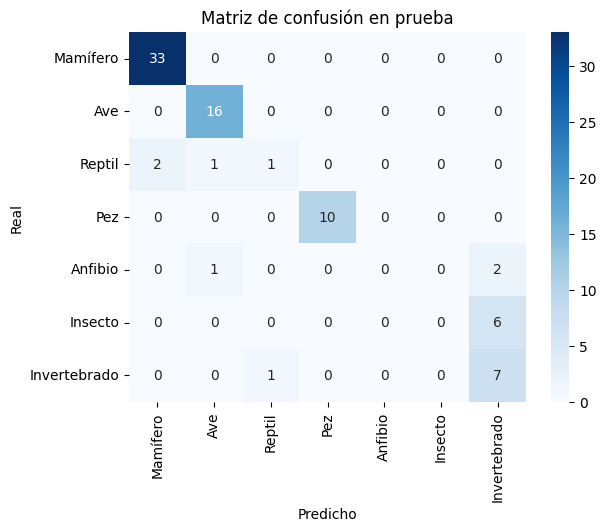

In [ ]:
# 6. Evaluación en entrenemiento
loss, acc = model.evaluate(X_train, y_train_cat, verbose=0)
print(f"\nPrecisión en el conjunto de prueba: {acc:.4f}")

# Predicciones y reporte
y_pred_probs = model.predict(X_train)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_train_cat, axis=1)

print("\nReporte de clasificación:")
print(classification_report(y_true, y_pred))

# Matriz de confusión

class_names = ['Mamífero','Ave', 'Reptil', 'Pez', 'Anfibio', 'Insecto','Invertebrado']
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de confusión en prueba")
plt.show()


Precisión en el conjunto de prueba: 0.8095
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94         8
           1       1.00      1.00      1.00         4
           2       0.00      0.00      0.00         1
           3       1.00      1.00      1.00         3
           4       0.00      0.00      0.00         1
           5       0.00      0.00      0.00         2
           6       0.40      1.00      0.57         2

    accuracy                           0.81        21
   macro avg       0.47      0.57      0.50        21
weighted avg       0.71      0.81      0.75        21



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


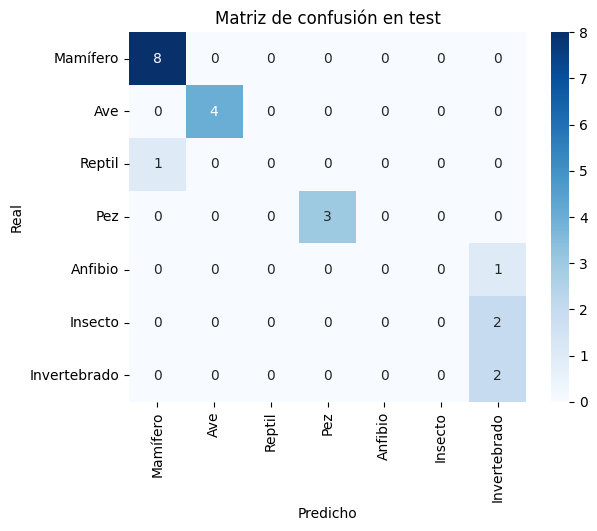

In [ ]:
# 6. Evaluación en test
loss, acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"\nPrecisión en el conjunto de prueba: {acc:.4f}")

# Predicciones y reporte
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

# Matriz de confusión

class_names = ['Mamífero','Ave', 'Reptil', 'Pez', 'Anfibio', 'Insecto','Invertebrado']
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de confusión en test")
plt.show()

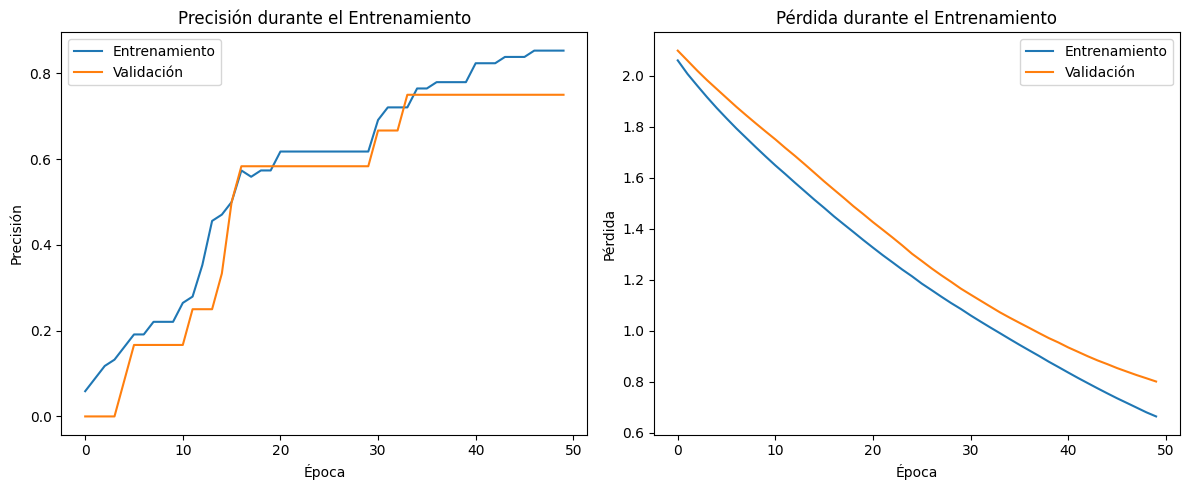

In [ ]:
# 7. Visualizar rendimiento
plt.figure(figsize=(12, 5))

# Precisión
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión durante el Entrenamiento')
plt.ylabel('Precisión')
plt.xlabel('Época')
plt.legend()

# Pérdida
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida durante el Entrenamiento')
plt.ylabel('Pérdida')
plt.xlabel('Época')
plt.legend()

plt.tight_layout()
plt.show()

# 8. Guardar el modelo (opcional)
# model.save('zoo_classifier_model.h5')

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml

# 1. Cargar dataset

import pandas as pd

# 1. Carga desde OpenML
htru = fetch_openml(data_id=45558, as_frame=True)
df = htru.frame

# 1-2. Renombrar columnas (opcional, para legibilidad)
columnas = [
    "Profile_mean", "Profile_stdev", "Profile_skewness", "Profile_kurtosis",
    "DM_mean",     "DM_stdev",    "DM_skewness",     "DM_kurtosis", "class"
]
df.columns = columnas

# 1-3. Verificar
print(df.shape)          # debe ser (17898, 9)
print(df['class'].value_counts())
df.head()

(17898, 9)
class
0    16259
1     1639
Name: count, dtype: int64


,Profile_mean,Profile_stdev,Profile_skewness,Profile_kurtosis,DM_mean,DM_stdev,DM_skewness,DM_kurtosis,class
0,140.562500,55.683782,-0.234571,-0.699648,3.199833,19.110426,7.975532,74.242225,0
1,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,0
2,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,0
3,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,0
4,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,0


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

📊 Reporte del clasificador básico:
              precision    recall  f1-score   support

   No pulsar       0.98      0.99      0.99      4878
      Pulsar       0.92      0.85      0.88       492

    accuracy                           0.98      5370
   macro avg       0.95      0.92      0.94      5370
weighted avg       0.98      0.98      0.98      5370



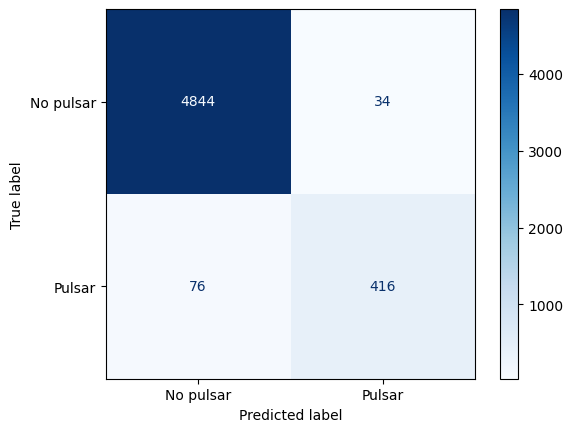

In [ ]:
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values  # 0 = no pulsar, 1 = pulsar

# 2. Preprocesamiento
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
y_cat = to_categorical(y, num_classes=2)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_cat, test_size=0.3, random_state=42, stratify=y)

# 3. Definición y entrenamiento del modelo
model = Sequential([
    Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(8, activation='relu'),
    Dense(2, activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_split=0.1, verbose=0)

# 4. Evaluación
y_pred = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print("\n📊 Reporte del clasificador básico:")
print(classification_report(y_true, y_pred_labels, target_names=['No pulsar','Pulsar']))

cm = confusion_matrix(y_true, y_pred_labels)
ConfusionMatrixDisplay(cm, display_labels=['No pulsar','Pulsar']).plot(cmap='Blues')
plt.show()

In [ ]:
from sklearn.utils import class_weight
import numpy as np

# Asumimos que y_train es one-hot y lo convertimos a etiquetas enteras
y_train_labels = np.argmax(y_train, axis=1)

# Convertir la lista de clases en un array de numpy
clases = np.array([0, 1])

# Calcular pesos
cw = class_weight.compute_class_weight(class_weight='balanced',
                                       classes=clases,
                                       y=y_train_labels)
class_weights = {clases[i]: cw[i] for i in range(len(clases))}

print("Pesos de clase:", class_weights)

# Ahora reentrenamos pasando class_weight
model_cw = Sequential([
    Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(8, activation='relu'),
    Dense(2, activation='softmax')
])
model_cw.compile(optimizer='adam',
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])

history_cw = model_cw.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    verbose=0,
    class_weight=class_weights
)







Pesos de clase: {np.int64(0): np.float64(0.5503910025481065), np.int64(1): np.float64(5.461203138622493)}


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


<Figure size 600x500 with 0 Axes>

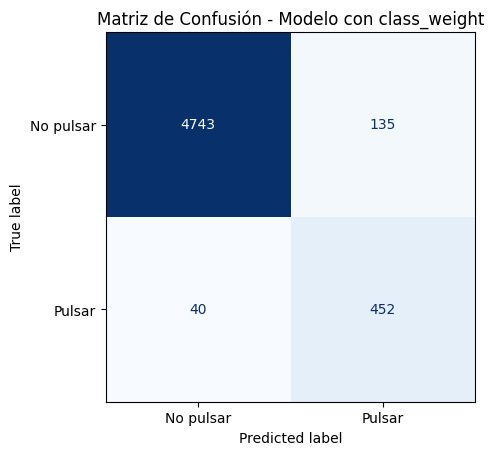

In [ ]:
# 1. Predecir probabilidades y convertir a etiquetas
y_pred_cw_probs = model_cw.predict(X_test)
y_pred_cw = np.argmax(y_pred_cw_probs, axis=1)

# 2. Convertir y_test (one-hot) a etiquetas enteras, si aún no lo hiciste
#    Si y_test está en formato one-hot:
# y_test_labels = np.argmax(y_test, axis=1)
#    Si y_test es ya un vector de 0/1, úsalo directamente:
y_test_labels = np.argmax(y_test, axis=1) if y_test.ndim > 1 else y_test

# 3. Calcular la matriz de confusión
cm_cw = confusion_matrix(y_test_labels, y_pred_cw)

# 4. Graficar
disp = ConfusionMatrixDisplay(confusion_matrix=cm_cw,
                              display_labels=['No pulsar', 'Pulsar'])
plt.figure(figsize=(6, 5))
disp.plot(cmap='Blues', colorbar=False)
plt.title("Matriz de Confusión - Modelo con class_weight")
plt.show()